In [1]:
import numpy as np
import matplotlib.pyplot as plt
#!pip install scipy
from scipy import optimize

## Single general constraint

### In a general (single) constrained we have:
- ### $K$ possible arms, each one associated to rewards $f_t(a) \in [0,1]$ and cost $c_t(a) \in [0,1]$
- ### $\rho$ per-round budget, and total budget $B=\rho T$
- ### Goal: minimize the regret (or pseudo regret) while satisfying the budget constraint

In [2]:
class SingleCostraintEnvironment:
    def __init__(self, F, C):
        self.F = F
        self.C = C
        self.t = 0

    def round(self):
        f_t = self.F[self.t,:]
        c_t = self.C[self.t,:]
        self.t +=1
        return f_t, c_t

### **Remark**: this is a simple and general implementation: $F,C$ can be adversarial or generated from a fixed stochastic distribution. The round method provides full-feedback, but we can give bandit feedback to the agent. If you prefer, you can implement specialized classes for the specific scenarios. 

### Stochastic Setting:
- ### $f_t(a) \sim D^\text{f}(a)$ i.i.d. mean $\bar f(a)$
- ### $c_t(a) \sim D^\text{c}(a)$ i.i.d. mean $\bar c(a)$
### The baseline is a clairvoyant that knows $D^\text{f},D^\text{c}$ in advance and maximizes the expected reward while satifying the constraint in expectation:

### $$ \text{maximize}_{x \in \Delta(A)} \;\;\; \sum_{t=1}^T \mathbb{E}_{a_t \sim x}[\bar f(a)] $$
### $$ \text{s.t.  }\;\;\; \sum_{t=1}^T\mathbb{E}_{a_t \sim x}[\bar c(a)] \le B,$$

### which can be rewritten as:
### $$ \text{maximize}_{x \in \Delta(A)} \;\;\; \mathbb{E}_{a_t \sim x}[\bar f(a)] $$
### $$ \text{s.t.  }\;\;\; \mathbb{E}_{a_t \sim x}[\bar c(a)] \le \rho$$

### Expanding th expectation:
### $$ \text{OPT}^{\text{S}} = \text{max}_{x \in \Delta(A)} \;\;\; \sum_{a \in A}x(a)\bar f(a) $$
### $$ \text{s.t.  }\;\;\; \sum_{a \in A}x(a)\bar c(a) \le \rho$$


### We minimize the pseudo regret:
### $$ R(T) = T \text{OPT}^{\text{S}} - \mathbb{E} \left [ \sum_{t \in [T]} f_t(a_t) \right] = T \text{OPT}^{\text{S}} - \mathbb{E} \left [ \sum_{t \in [T]} f_t(x_t) \right], $$
### where the expectation is over the randomization induced by the environment and the learning algorithm.

In [3]:
## Linear Program
def compute_clairvoyant(f, c, rho):
    A_ub = [c]
    b_ub = [rho]
    A_eq = [np.ones(len(f))]
    b_eq = [1]
    res = optimize.linprog(-f, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0,1))
    x = res.x
    
    # we return the distribution, the reward, 
    return x, -res.fun, c @ x

### Adversarial Setting:
### $f_t, c_t$ can be any
### The baseline is the best fixed distribution in hindsight that satisfies the budget constraint in expectation

### $$ \text{OPT}^{\text{A}} = \text{max}_{x \in \Delta(A)} \;\;\; \sum_{a \in A}x(a)\hat f(a) $$
### $$ \text{s.t.  }\;\;\; \sum_{a \in A}x(a)\hat c(a) \le \rho,$$

### where
### $$ \hat f(a) = \frac{1}{T} \sum_{t \in [T]} f_t(a) \;\;\text{and}\;\; \hat c(a) = \frac{1}{T} \sum_{t \in [T]} c_t(a) $$


### It can be computed by *compute_clairvoyant*

### We minimize the regret:

### $$ R(T) = T \text{OPT}^{\text{A}} - \mathbb{E} \left [ \sum_{t \in [T]} f_t(a_t) \right] = T \text{OPT}^{\text{A}} - \mathbb{E} \left [ \sum_{t \in [T]} f_t(x_t) \right], $$
### where the expectation is w.r.t the randomization induced by the algorithm only.


### In the worst case, we can compete only against $\rho \text{OPT}^{\text{A}}$.

## Towards a regret minimizer
### The problem:
### $$ \text{max}_{x \in \Delta(A)} \;\;\; \sum_{a \in A}x(a) f(a) $$
### $$ \text{s.t.  }\;\;\; \sum_{a \in A}x(a) c(a) \le \rho,$$
### for any $f,c$, is equivalent to:
### $$ \max_{x \in \Delta(A)} \min_{\lambda \in [0,1/\rho]} L(x,\lambda,f,c) = \min_{\lambda \in [0,1/\rho]}\max_{x \in \Delta(A)} L(x,\lambda,f,c), $$
### where the Lagrangian function is:
### $$ L(x,\lambda,f,c) = \mathbb{E}_{a \sim x}[f(a)] + \lambda(\rho -\mathbb{E}_{a \sim x}[c(a)])$$

### Idea: use a (primal) regret maximizer to choose $x$ to maximize $L$, and a (dual) regret minimizer to choose $\lambda$ to minimize it.
### Remark: A primal regret maximizer for $L$ is equivalent to a primal regret minimizers for $-L$
### Formally, the loss $\ell^{\text{P}}_t$ of the primal regret minimizer is:
### $$ \ell^{\text{P}}_t(a) = - (f_t(a) - \lambda_t c_t(a))$$
### And the loss of $\ell^{\text{D}}_t$ of the dual regret minimizer is:
### $$ \ell^{\text{D}}_t(\lambda) = \lambda (\rho -\mathbb{E}_{a \sim x_t}[c_t(a)])$$ 

### With **full feedback** we can use Hedge as primal regret minimizer.
### The dual variable $\lambda$ is continous: we cannot use Hedge.
### We use OGD as dual regret minimizer, the update rule is:
### $$ \lambda_{t+1} = \Pi_{[0,1/\rho]} (\lambda_t - \eta(\rho -\mathbb{E}_{a \sim x_t}[c_t(a)]))$$

In [4]:
class HedgeAgent:
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.x_t = np.ones(K)/K
        self.a_t = None
        self.t = 0

    def choose_distribution(self):
        self.x_t = self.weights/sum(self.weights)
        # self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        # slight difference: we return x_t
        return self.x_t
    
    def update(self, l_t):
        self.weights *= np.exp(-self.learning_rate*l_t)
        self.t += 1

In [5]:
class OGDHedgeSingleKnapsackAgent:
    def __init__(self, K, rho, T, hedge_eta, ogd_eta):
        self.K = K
        self.hedge = HedgeAgent(self.K, hedge_eta)
        self.budget = rho*T
        self.ogd_eta = ogd_eta
        self.T = T
        self.rho = rho
        self.lmbd = 1
        self.t = 0
        self.N_pulls = np.zeros(K)
        self.x_t = np.ones(K)
        self.a_t = 0

    def pull_arm(self):
        if self.budget < 1:
            self.a_t = 0
            self.x_t = np.zeros(self.K)
            self.x_t[0] = 1            
            return 0
        self.x_t = self.hedge.choose_distribution()
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t
    
    def update(self, f_t, c_t):
        # f_t vector of rewards, c_t vector of costs all in [0,1]
        # update hedge
        primal_reward_t = f_t - self.lmbd*c_t # in [-1,+1] component-wise
        primal_reward_t = (primal_reward_t + 1) / 2 # either rescale in [0,1] or slightly change eta

        self.hedge.update(1 -primal_reward_t) # we need to maximize L

        # update lagrangian multiplier
        self.lmbd = np.clip(self.lmbd-self.ogd_eta*(self.rho-c_t@self.x_t), 
                            a_min=0, a_max=1/self.rho)
        # self.lmbd = self.lmbd-self.ogd_eta*(self.rho-c_t@self.x_t) # in principle it works even without bounds
        # update budget
        self.budget -= c_t[self.a_t]
        # log
        self.N_pulls[self.a_t] += 1

## Stochastic example

### A single trial

In [6]:
rho = 0.4
f = np.array([0,0.8,0.5])
c = np.array([0,0.6,0.3]) 

# note that the clairvoyant may use the opt-out arm (try this example)
# rho = 0.4
# f = np.array([0,0.7, 0.6])
# c = np.array([0,0.45,0.4])

K = len(f)
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(f, c, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

Distribution: [0.         0.33333333 0.66666667]
Utility: 0.6000000000000001
Cost: 0.4


In [7]:
rho = 0.4
f = np.array([0,0.8,0.5])
c = np.array([0,0.6,0.3]) 
K = len(f)
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(f, c, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

T = 10**5
ogd_eta = 1/np.sqrt(T)
hedge_eta = np.sqrt(np.log(K)/T)
agent = OGDHedgeSingleKnapsackAgent(K, rho=rho, T=T, ogd_eta=ogd_eta, hedge_eta=hedge_eta)


utilities = np.zeros(T)
costs = np.zeros(T)
lmbds = np.zeros(T)

rounds_with_depleted_budget = 0

np.random.seed(17)
epsilon = 0.1
F = np.random.uniform(f-epsilon,f+epsilon,size=(T,K))
F[:,0] = 0 # force the first arm to be the opt-out arm 
C = np.random.uniform(c-epsilon,c+epsilon,size=(T,K))
C[:,0] = 0 # force the first arm to be the opt-out arm
# F = np.random.binomial(n=1, p=f, size=(T, K))
# C = np.random.binomial(n=1, p=c, size=(T, K))
env = SingleCostraintEnvironment(F,C)
for t in range(T):
    # interaction
    a_t = agent.pull_arm()
    f_t, c_t = env.round()
    agent.update(f_t, c_t)

    # logging
    # utilities[t] = f_t[a_t]
    # costs[t] = c_t[a_t]
    utilities[t] = f_t @ agent.x_t
    costs[t] = c_t @ agent.x_t
    lmbds[t] = agent.lmbd
    if(agent.budget < 1 and rounds_with_depleted_budget==0):
        rounds_with_depleted_budget = T - t

Distribution: [0.         0.33333333 0.66666667]
Utility: 0.6000000000000001
Cost: 0.4


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\287686727.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\287686727.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\287686727.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum c_t$')


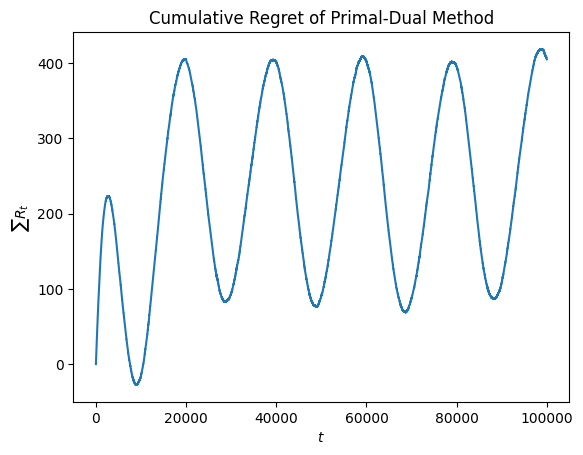

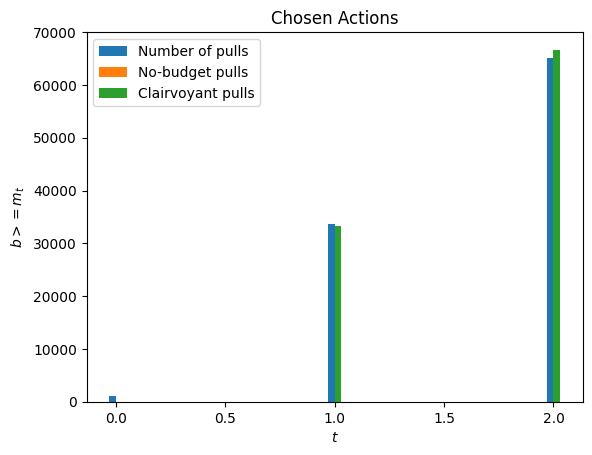

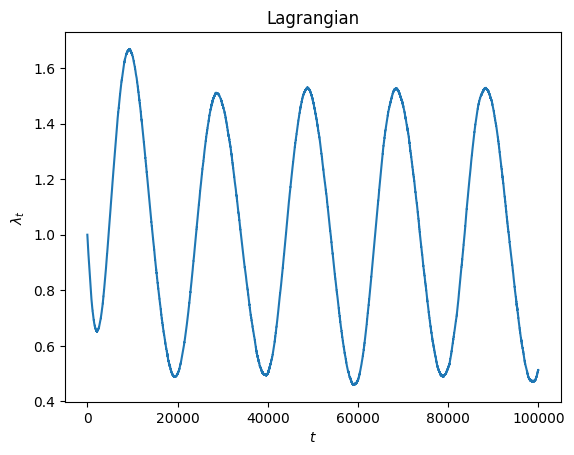

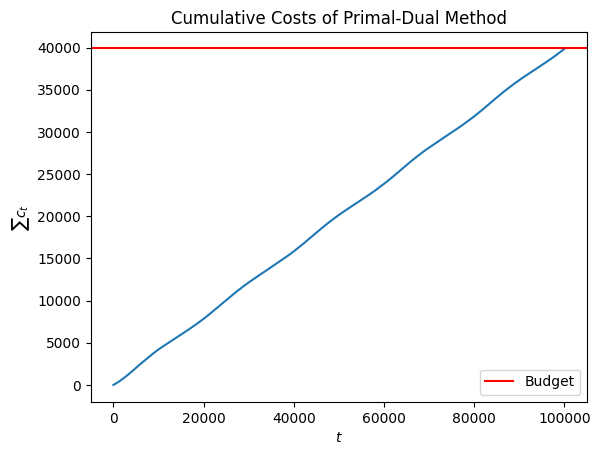

153.85371692448098


In [8]:
cumulative_regret = np.cumsum(clairvoyant_utility-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method')
plt.show()

plt.title("Chosen Actions")
width = 0.03
plt.bar(np.arange(K) -width/2, agent.N_pulls, width=width, align='center', label='Number of pulls')
plt.bar(0 -width/2, rounds_with_depleted_budget, width=width, align='center', label='No-budget pulls')
plt.bar(np.arange(K) +width/2, clairvoyant_x*T, width=width, align='center', label='Clairvoyant pulls')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

plt.plot(lmbds)
plt.xlabel('$t$')
plt.ylabel('$\lambda_t$')
plt.title('Lagrangian')
plt.show()

cumulative_costs = np.cumsum(costs)
plt.plot(cumulative_costs)
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(rho*T, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Costs of Primal-Dual Method')
plt.show()
print(rho*T - cumulative_costs[-1])

### To complete the estimation, we need to average over multiple rounds

In [9]:
rho = 0.4
f = np.array([0,0.8,0.5])
c = np.array([0,0.6,0.3]) 
# note: if no arm satisfyes c <= rho, then you need to explicitly add an opt-out arm
K = len(f)
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(f, c, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

n_trials = 10
T = 10**4
ogd_eta = 1/np.sqrt(T)
hedge_eta = np.sqrt(np.log(K)/T)

regret_for_trial = []
costs_for_trial = []
lmbds_for_trial = []

for seed in range(n_trials):
    np.random.seed(seed)
    print('Trial ',seed)
    agent = OGDHedgeSingleKnapsackAgent(K, rho=rho, T=T, ogd_eta=ogd_eta, hedge_eta=hedge_eta)

    utilities = np.zeros(T)
    costs = np.zeros(T)
    lmbds = np.zeros(T)

    rounds_with_depleted_budget = 0

    np.random.seed(17)
    epsilon = 0.3 # increased variance
    F = np.random.uniform(f-epsilon,f+epsilon,size=(T,K))
    F[:,0] = 0
    C = np.random.uniform(c-epsilon,c+epsilon,size=(T,K))
    C[:,0] = 0
    env = SingleCostraintEnvironment(F,C)
    for t in range(T):
        # interaction
        a_t = agent.pull_arm()
        f_t, c_t = env.round()
        agent.update(f_t, c_t)

        # logging
        # utilities[t] = f_t[a_t]
        # costs[t] = c_t[a_t]
        # robust estimation
        utilities[t] = f_t @ agent.x_t
        costs[t] = c_t @ agent.x_t
        lmbds[t] = agent.lmbd
    regret_for_trial.append(np.cumsum(clairvoyant_utility - utilities))
    costs_for_trial.append(np.cumsum(costs))
    lmbds_for_trial.append(lmbds)


Distribution: [0.         0.33333333 0.66666667]
Utility: 0.6000000000000001
Cost: 0.4
Trial  0
Trial  1
Trial  2
Trial  3
Trial  4
Trial  5
Trial  6
Trial  7
Trial  8
Trial  9


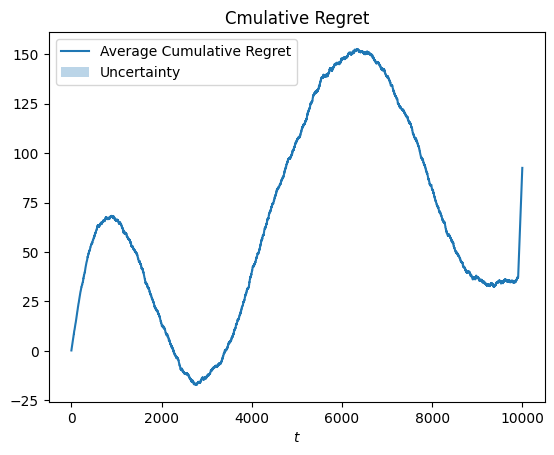

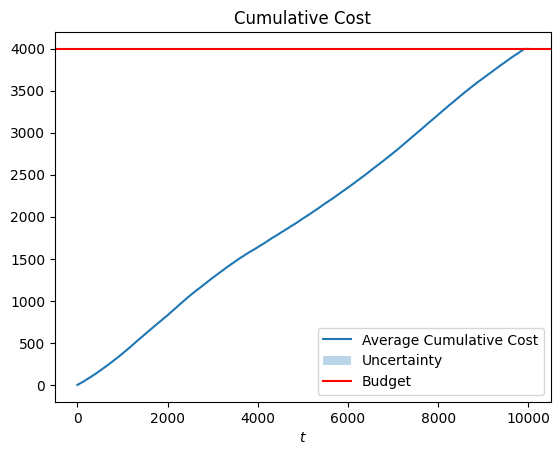

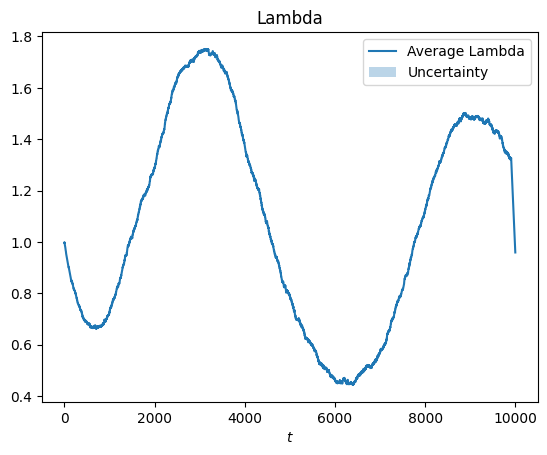

In [10]:
regret_for_trial = np.array(regret_for_trial)
costs_for_trial = np.array(costs_for_trial)
lmbds_for_trial = np.array(lmbds_for_trial)

average_regret = regret_for_trial.mean(axis=0)
average_costs = costs_for_trial.mean(axis=0)
average_lmbds = lmbds_for_trial.mean(axis=0)

std_regret = regret_for_trial.std(axis=0)
std_costs = costs_for_trial.std(axis=0)
std_lmbds = lmbds_for_trial.std(axis=0)

plt.plot(np.arange(T), average_regret, label='Average Cumulative Regret')
plt.fill_between(np.arange(T),
                average_regret-std_regret/np.sqrt(n_trials),
                average_regret+std_regret/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.title('Cmulative Regret')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.plot(np.arange(T), average_costs, label='Average Cumulative Cost')
plt.fill_between(np.arange(T),
                average_costs-std_costs/np.sqrt(n_trials),
                average_costs+std_costs/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.title('Cumulative Cost')
plt.axhline(rho*T, color='red', label='Budget')
plt.xlabel('$t$')
plt.legend()
plt.show()

plt.plot(np.arange(T), average_lmbds, label='Average Lambda')
plt.fill_between(np.arange(T),
                average_lmbds-std_lmbds/np.sqrt(n_trials),
                average_lmbds+std_lmbds/np.sqrt(n_trials),
                alpha=0.3,
                label='Uncertainty')
plt.title('Lambda')
plt.xlabel('$t$')
plt.legend()
plt.show()

## Adversarial Setting

### We test the algorithm in the two "bad" instances that we say in theory

### First instance

In [11]:
rho = 0.5
f_1 = np.array([0,0.1, 0.05])
c_1 = np.array([0,0.9,0.95])
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(f_1, c_1, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)
print('----------------')
f_2 = np.array([0,0.0, 0.0,])
c_2 = np.array([0,0.0,0.0])
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(f_2, c_2, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)
print('----------------')

np.random.seed(10)
T1 = 10**3
F_1 = np.random.binomial(n=1,p=f_1,size=(T1,K))
C_1 = np.random.binomial(n=1,p=c_1,size=(T1,K))
F_2 = np.random.binomial(n=1,p=f_2,size=(T1,K))
C_2 = np.random.binomial(n=1,p=c_2,size=(T1,K))
F = np.concatenate([F_1,F_2])
C = np.concatenate([C_1,C_2])
avg_f = F.mean(axis=0)
avg_c = C.mean(axis=0)
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(avg_f, avg_c, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)
print('----------------')

Distribution: [0.44444444 0.55555556 0.        ]
Utility: 0.05555555555555556
Cost: 0.5
----------------
Distribution: [1. 0. 0.]
Utility: -0.0
Cost: 0.0
----------------
Distribution: [ 0.  1. -0.]
Utility: 0.053
Cost: 0.458
----------------


In [12]:
np.random.seed(10)
T1 = 10**3
F_1 = np.random.binomial(n=1,p=f_1,size=(T1,K))
C_1 = np.random.binomial(n=1,p=c_1,size=(T1,K))
F_2 = np.random.binomial(n=1,p=f_2,size=(T1,K))
C_2 = np.random.binomial(n=1,p=c_2,size=(T1,K))
F = np.concatenate([F_1,F_2])
C = np.concatenate([C_1,C_2])
avg_f = F.mean(axis=0)
avg_c = C.mean(axis=0)
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant(avg_f, avg_c, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)
T = F.shape[0]
print('T:',t)
print('----------------')


ogd_eta = 1/np.sqrt(T)
hedge_eta = np.sqrt(np.log(K)/T)
agent = OGDHedgeSingleKnapsackAgent(K, rho=rho, T=T, ogd_eta=ogd_eta, hedge_eta=hedge_eta)


utilities = np.zeros(T)
costs = np.zeros(T)
lmbds = np.zeros(T)

rounds_with_depleted_budget = 0

np.random.seed(17)
env = SingleCostraintEnvironment(F,C)
for t in range(T):
    # interaction
    a_t = agent.pull_arm()
    f_t, c_t = env.round()
    agent.update(f_t, c_t)

    # logging
    # utilities[t] = f_t[a_t]
    # costs[t] = c_t[a_t]
    utilities[t] = f_t @ agent.x_t
    costs[t] = c_t @ agent.x_t
    lmbds[t] = agent.lmbd
    if(agent.budget < 1 and rounds_with_depleted_budget==0):
        rounds_with_depleted_budget = T - t

Distribution: [ 0.  1. -0.]
Utility: 0.053
Cost: 0.458
T: 9999
----------------


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\297407325.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\297407325.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\297407325.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum c_t$')


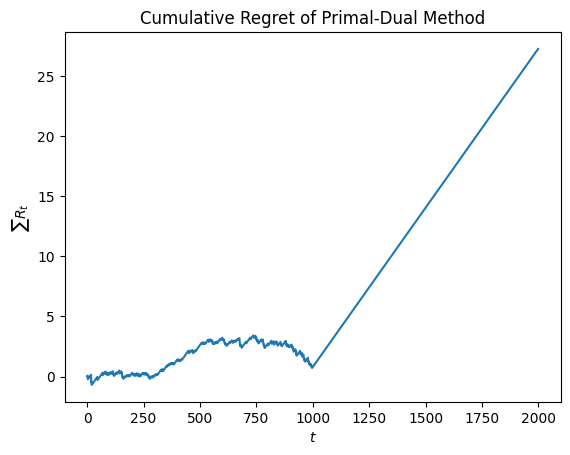

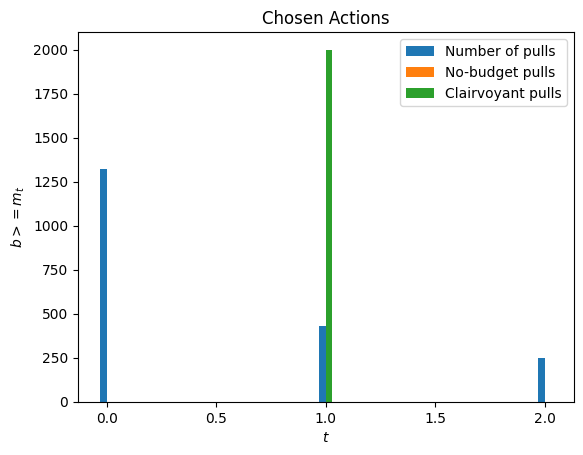

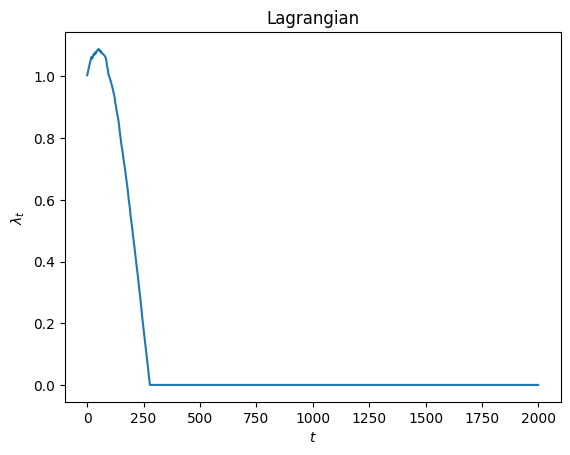

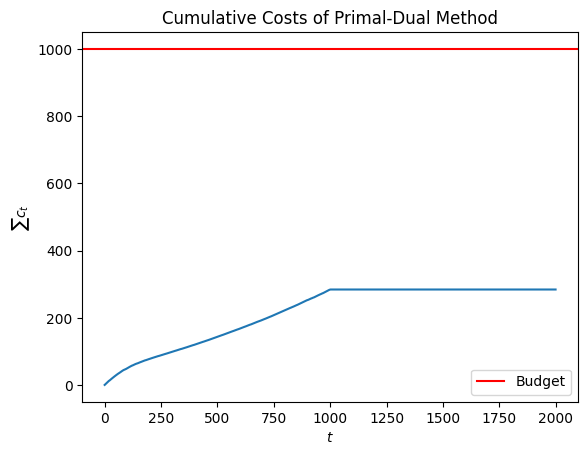

In [13]:
cumulative_regret = np.cumsum(rho*clairvoyant_utility-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method')
plt.show()

plt.title("Chosen Actions")
width = 0.03
plt.bar(np.arange(K) -width/2, agent.N_pulls, width=width, align='center', label='Number of pulls')
plt.bar(0 -width/2, rounds_with_depleted_budget, width=width, align='center', label='No-budget pulls')
plt.bar(np.arange(K) +width/2, clairvoyant_x*T, width=width, align='center', label='Clairvoyant pulls')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

plt.plot(lmbds)
plt.xlabel('$t$')
plt.ylabel('$\lambda_t$')
plt.title('Lagrangian')
plt.show()

cumulative_costs = np.cumsum(costs)
plt.plot(cumulative_costs)
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(rho*T, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Costs of Primal-Dual Method')
plt.show()

### Notice that we computed the regret as the difference between $\rho\text{OPT}^{\text{A}}$ and the reward collected by our algorithm.
### We could instead use the actual instantaneous rewards of the baseline: it plays always the second arm.

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\1333133696.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\1333133696.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')


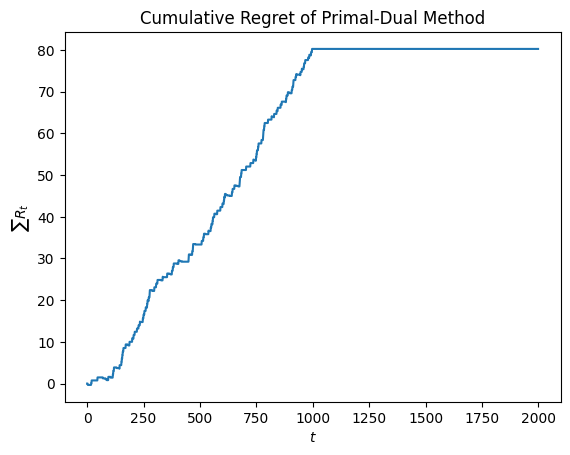

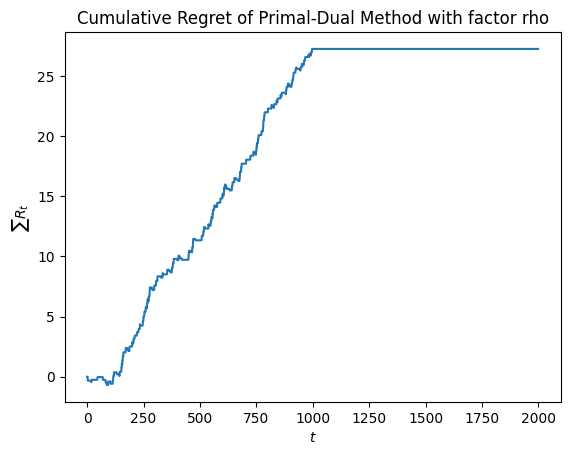

Clairvoyant utility: 106.0


In [14]:
cumulative_regret = np.cumsum(F@clairvoyant_x-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method')
plt.show()

cumulative_regret = np.cumsum(rho*(F@clairvoyant_x)-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method with factor rho')
plt.show()

print('Clairvoyant utility:',clairvoyant_utility*T)

# Multiple Constraints

### In a general constrained bandit problem we have:
- ### $K$ possible arms, each one associated to rewards $f_t(a) \in [0,1]$ and M costs $c_{t,i}(a) \in [0,1]$ for evey $t \in [T]$
- ### $\rho_i$ per-round budget, and total budget $B_i=\rho_i T$ for every constraint $i \in [M]$
- ### Goal: minimize the regret (or pseudo regret) while satisfying all budget constraints

In [15]:
class MultiCostraintEnvironment:
    def __init__(self, F, C):
        self.F = F # this is a matrix (T,K)
        self.C = C # this is a tensor (T,m,K)
        self.t = 0

    def round(self):
        f_t = self.F[self.t,:]
        C_t = self.C[self.t,:,:]
        self.t +=1
        return f_t, C_t

### Stochastic Setting:
- ### $f_t(a) \sim D^\text{f}(a)$ i.i.d. mean $\bar f(a)$
- ### $c_{t,i}(a) \sim D^\text{c}_i(a)$ i.i.d. mean $\bar c_i(a)$ for every $i \in [M]$
### The baseline is a clairvoyant that knows $D^\text{f},D^\text{c}$ in advance and maximizes the expected reward while satifying the constraints in expectation:

### $$ \text{OPT}^{\text{S}} = \text{max}_{x \in \Delta(A)} \;\;\; \sum_{a \in A}x(a)\bar f(a) $$
### $$ \text{s.t.  }\;\;\; \sum_{a \in A}x(a)\bar c_i(a) \le \rho_i \quad \forall i \in [M]$$


### We minimize the pseudo regret:
### $$ R(T) = T \text{OPT}^{\text{S}} - \mathbb{E} \left [ \sum_{t \in [T]} f_t(a_t) \right] = T \text{OPT}^{\text{S}} - \mathbb{E} \left [ \sum_{t \in [T]} f_t(x_t) \right], $$
### where the expectation is over the randomization induced by the environment and the learning algorithm.

### Adversarial Setting: the sequence of $f_t, c_{t,i}$ can be arbitrary.
### The baseline is the best fixed distribution in hindsight that satisfies the budget constraints in expectation:

### $$ \text{OPT}^{\text{A}} = \text{max}_{x \in \Delta(A)} \;\;\; \sum_{a \in A}x(a)\hat f(a) $$
### $$ \text{s.t.  }\;\;\; \sum_{a \in A}x(a)\hat c_i(a) \le \rho_i \quad \forall i \in [M],$$

### where
### $$ \hat f(a) = \frac{1}{T} \sum_{t \in [T]} f_t(a) \;\;\text{and}\;\; \hat c_i(a) = \frac{1}{T} \sum_{t \in [T]} c_{t,i}(a) $$

In [16]:
## Linear Program
def compute_clairvoyant_multi(f, C, rho):
    A_ub = C
    b_ub = rho
    A_eq = [np.ones(len(f))]
    b_eq = [1]
    # print('A_ub',A_ub.shape,'b_up',b_ub.shape)
    res = optimize.linprog(-f, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0,1))
    x = res.x
    
    # we return the distribution, the reward, 
    return x, -res.fun, C @ x

## Extending the Primal-Dual method
### The problem:
### $$ \text{max}_{x \in \Delta(A)} \;\;\; \sum_{a \in A}x(a) f(a) $$
### $$ \text{s.t.  }\;\;\; \sum_{a \in A}x(a) c_i(a) \le \rho_i \quad \forall i \in [M],$$
### for any $f \in [0,1]^K,c \in [0,1]^{M\times K}$ is equivalent to:
### $$ \max_{x \in \Delta(A)} \min_{\lambda \in D} L(x,\lambda,f,c) = \min_{\lambda \in D}\max_{x \in \Delta(A)} L(x,\lambda,f,c), $$
### where the Lagrangian function is:
### $$ L(x,\lambda,f,c) = \mathbb{E}_{a \sim x}[f(a)] + \langle \lambda, \rho -\mathbb{E}_{a \sim x}[c(a)] \rangle,$$
### and the domain $D$ of $\lambda$ is the hyperrectangle $D = \{\lambda \in \mathbb{R}^M : 0 \le \lambda_i \le 1/\rho_i \; \forall i \in [M]\}$.
### **Remark**: $\mathbb{E}_{a \sim x}[c(a)]$ is a vector in $[0,1]^M$, with the expected cost for each constraint.

### We can extend the previous idea.
### Use a (primal) regret maximizer to choose $x$ to maximize $L$, and a (dual) regret minimizer to choose $\lambda$ to minimize it.
### Remark: A primal regret maximizer for $L$ is equivalent to a primal regret minimizers for $-L$
### Formally, the loss $\ell^{\text{P}}_t$ of the primal regret minimizer is:
### $$ \ell^{\text{P}}_t(a) = - (f_t(a) - \langle\lambda_t, c_t(a)\rangle),$$ where $c_t(a) \in [0,1]^M$.
### The loss of $\ell^{\text{D}}_t$ of the dual regret minimizer is:
### $$ \ell^{\text{D}}_t(\lambda) = \langle \lambda, \rho -\mathbb{E}_{a \sim x_t}[c_t(a)] \rangle$$ 

### We use OGD as dual regret minimizer, the update rule is:
### $$ \lambda_{t+1,i} = \Pi_{[0,1/\rho_i]} (\lambda_{t,i} - \eta(\rho_i -\mathbb{E}_{a \sim x_t}[c_{t,i}(a)]))$$

In [17]:
class OGDHedgeMultiKnapsackAgent:
    def __init__(self, K, rho, T, hedge_eta, ogd_eta):
        self.K = K
        self.m = len(rho)
        # self.hedge = HedgeAgentCC(self.K, hedge_eta,1/T)
        self.hedge = HedgeAgent(self.K, hedge_eta)
        self.budget = rho*T
        self.ogd_eta = ogd_eta
        self.T = T
        self.rho = rho # vector
        self.lmbd = np.ones(self.m) # vector
        self.t = 0
        self.N_pulls = np.zeros(K)
        self.x_t = np.ones(K)
        self.a_t = 0

    def pull_arm(self):
        if (self.budget < 1).any():
            self.a_t = 0
            self.x_t = np.zeros(self.K)
            self.x_t[0] = 1            
            return 0
        self.x_t = self.hedge.choose_distribution()
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t
    
    def update(self, f_t, C_t):
        # f_t vector of rewards, C_t matrix of costs (M,K) all in [0,1]
        # update hedge
        # primal_reward_t[i] = f_t[i] - np.dot(lmbd,C_t[:,i]) for every constraint i
        primal_reward_t = f_t - self.lmbd @ C_t # in [-1,+1] component-wise
        primal_reward_t = (primal_reward_t + 1) / 2 # either rescale in [0,1] or slightly change eta

        self.hedge.update(1 -primal_reward_t) # we need to maximize L

        # update lagrangian multiplier
        # self.lmbd[i] = np.clip(self.lmbd[i]-self.ogd_eta*(self.rho-C_t[i,:]@self.x_t),
        #                        a_min=0, a_max=1/self.rho) # for every i
        self.lmbd = np.clip(
            self.lmbd - self.ogd_eta * (self.rho - C_t @ self.x_t),
            a_min=0, 
            a_max=1 / self.rho
        )
        # update budget
        self.budget -= C_t[:,self.a_t]
        # log
        self.N_pulls[self.a_t] += 1

In [18]:
rho = np.array([0.4,0.4])
f = np.array([0,0.8,0.5])
C = np.array([[0,0.6,0.3],
              [0,0.5,0.6]]) 

K = len(f)
M = C.shape[0]
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant_multi(f, C, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

Distribution: [0.23809524 0.57142857 0.19047619]
Utility: 0.5523809523809524
Cost: [0.4 0.4]


In [19]:
rho = np.array([0.4,0.4])
f = np.array([0,0.8,0.5])
C = np.array([[0,0.6,0.3],
              [0,0.5,0.6]]) 

K = len(f)
M = C.shape[0]
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant_multi(f, C, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

T = 10**5
ogd_eta = 1/np.sqrt(T)
hedge_eta = np.sqrt(np.log(K)/T)
agent = OGDHedgeMultiKnapsackAgent(K, rho=rho, T=T, ogd_eta=ogd_eta, hedge_eta=hedge_eta)


utilities = np.zeros(T)
costs = np.zeros((T,M))
lmbds = np.zeros((T,M))

rounds_with_depleted_budget = 0

np.random.seed(17)
F_samples = np.random.binomial(n=1, p=f, size=(T, K))
C_samples = np.random.binomial(1, C, size=(T, M, K))
env = MultiCostraintEnvironment(F_samples,C_samples)
for t in range(T):
    # interaction
    a_t = agent.pull_arm()
    f_t, C_t = env.round()
    agent.update(f_t, C_t)

    # logging
    # utilities[t] = f_t[a_t]
    # costs[t] = c_t[a_t]
    utilities[t] = f_t @ agent.x_t
    costs[t] = C_t @ agent.x_t
    lmbds[t] = agent.lmbd
    if((agent.budget < 1).any() and rounds_with_depleted_budget==0):
        rounds_with_depleted_budget = T - t

Distribution: [0.23809524 0.57142857 0.19047619]
Utility: 0.5523809523809524
Cost: [0.4 0.4]


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\1023164359.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\1023164359.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\1023164359.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.legend([f"$\lambda_{{{i}}}$" for i in range(lmbds.shape[1])])
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\1023164359.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sum 

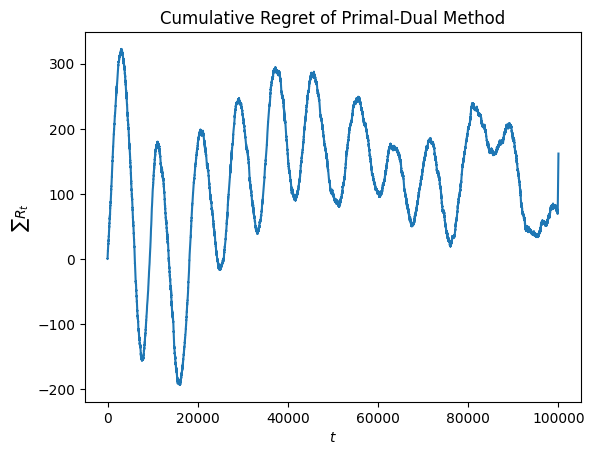

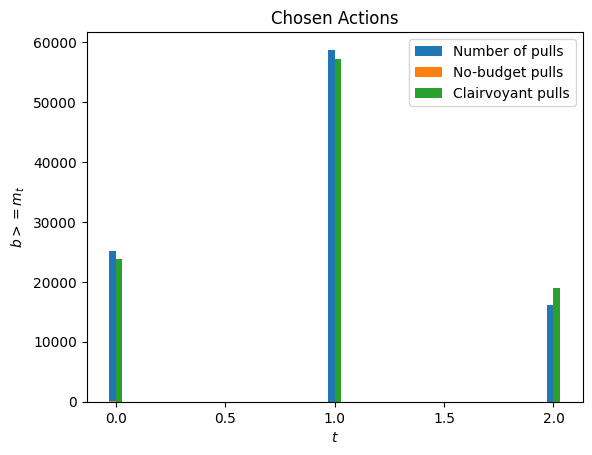

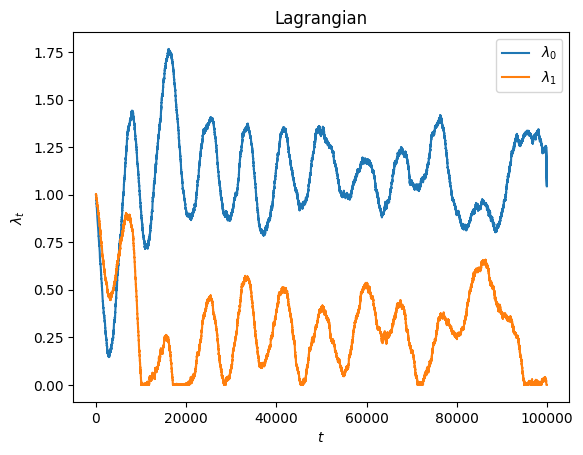

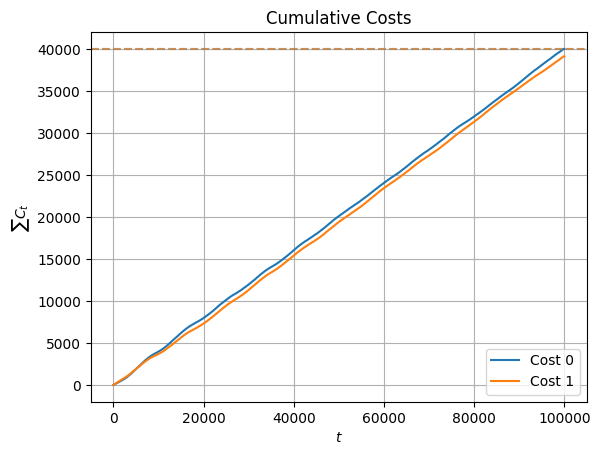

In [20]:
cumulative_regret = np.cumsum(clairvoyant_utility-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method')
plt.show()

plt.title("Chosen Actions")
width = 0.03
plt.bar(np.arange(K) -width/2, agent.N_pulls, width=width, align='center', label='Number of pulls')
plt.bar(0 -width/2, rounds_with_depleted_budget, width=width, align='center', label='No-budget pulls')
plt.bar(np.arange(K) +width/2, clairvoyant_x*T, width=width, align='center', label='Clairvoyant pulls')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

plt.plot(lmbds)
plt.xlabel('$t$')
plt.ylabel('$\lambda_t$')
plt.legend([f"$\lambda_{{{i}}}$" for i in range(lmbds.shape[1])])
plt.title('Lagrangian')
plt.show()

cum_costs = np.cumsum(costs, axis=0)
lines = plt.plot(cum_costs)
for i in range(M):
    plt.axhline(y=rho[i]*T, color=lines[i].get_color(), linestyle='--', alpha=0.6)
plt.legend([f"Cost {i}" for i in range(costs.shape[1])])
plt.xlabel("$t$")
plt.ylabel("$\sum C_t$")
plt.title("Cumulative Costs")
plt.grid(True)
plt.show()

### **Remark**: since this is a stochastic setting, to complete the estiamtion of the pseudo regret you need to run multiple trials.

## Bandit Feedback

### We can still use a slightly modified OGD as dual minimizers:
### $$ \lambda_{t+1,i} = \Pi_{[0,1/\rho_i]} (\lambda_{t,i} - \eta(\rho_i -c_{t,i}(a_t)))$$

### We cannot use Hedge as primal minimizers. We need an algorithm that uses bandit-feedback and provide high-probability guarantees.
### **Remark**: EXP3 provides guarantees in epxectation, not in high probability.
### We need a new algorithm EXP3-IX, which provides high-probability guarantees

### New loss estimator:
### $$ \hat \ell_t(a) = \frac{\ell_t(a)}{x_{t(a)} +\gamma} \mathbb{I}\{a_t=a\}$$ 
### This estimator introduces a bias and forces (implicitly some eploration).
### EXP3-IX has less variance than EXP3 and provides high-probability guarantees.

In [21]:
class AdversarialBanditEnvironment:
    def __init__(self, loss_sequence):
        self.loss_sequence = loss_sequence
        self.t = 0

    def round(self, a_t): # we need to receive a specific arm
        l_t = self.loss_sequence[self.t, a_t] ## we return only the loss corresponding to the chosen arm
        self.t+=1 
        return l_t

In [22]:
class EXP3Agent:
    def __init__(self, K, learning_rate):
        self.K = K
        self.learning_rate = learning_rate
        self.weights = np.ones(K)
        self.a_t = None
        self.x_t = np.ones(K)/K
        self.N_pulls = np.zeros(K)
        self.t = 0

    def pull_arm(self):
        self.x_t = self.weights/sum(self.weights)
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t
    
    def update(self, l_t):
        l_t_tilde = l_t/self.x_t[self.a_t]
        self.weights[self.a_t] *= np.exp(-self.learning_rate*l_t_tilde)
        self.N_pulls[self.a_t] += 1
        self.t += 1

In [23]:
class EXP3IXAgent:
    def __init__(self, K, eta, gamma):
        self.K = K
        self.T = T
        self.eta = eta
        self.gamma = gamma
        self.weights = np.ones(K) 
        self.x_t = np.ones(K) / K
        self.a_t = None
        self.N_pulls = np.zeros(K)
        self.t = 0

    def pull_arm(self):
        self.x_t = self.weights/sum(self.weights)
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t
    
    def update(self, l_t):
        l_hat_t = l_t / (self.x_t[self.a_t] + self.gamma)
        self.weights[self.a_t] *= np.exp(-self.eta*l_hat_t)
        # if np.sum(self.weights) < 1e-100:
        #     self.weights /= np.max(self.weights)
        self.N_pulls[self.a_t] += 1
        self.t += 1

In [24]:
T = 10**4
K = 3
loss_seq = np.zeros((T, K))
np.random.seed(17)
loss_seq[:,0] = np.random.binomial(n=1, p=0.7, size=T)
loss_seq[:,1] = np.random.binomial(n=1, p=0.5, size=T)
loss_seq[:,2] = np.random.binomial(n=1, p=0.25, size=T)

Best arm in hindsight: 2
Trial 1
Trial 2
Trial 3
Trial 4
Trial 5
Trial 6
Trial 7
Trial 8
Trial 9
Trial 10


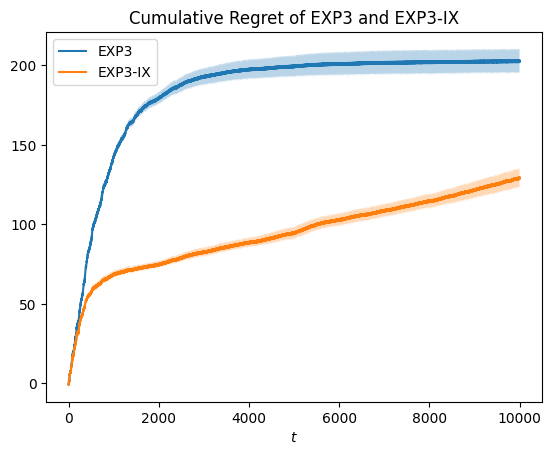

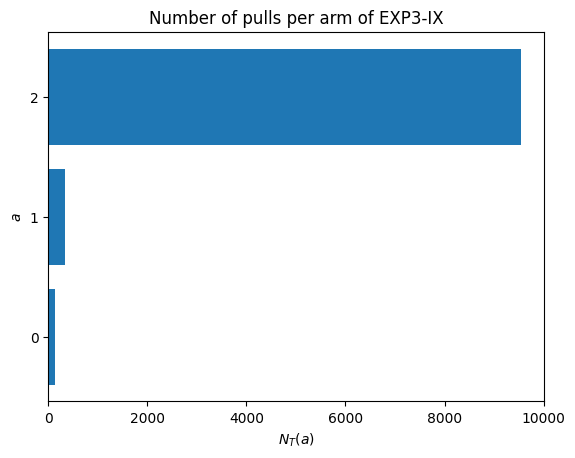

In [25]:
delta = 1/T
learning_rate_ix = np.sqrt((np.log(K)+np.log((K+1)/delta))/(K*T)) # better regret for a specific delta
# learning_rate_ix = np.sqrt((2*np.log(K+1))/(K*T)) # high probability bound for every delta
gamma = learning_rate_ix/2

learning_rate = np.sqrt(np.log(K)/(K*T))

best_arm = np.argmin(loss_seq.sum(axis=0))
clairvoyant_losses = loss_seq[:, best_arm]
print('Best arm in hindsight:',best_arm)

n_trials = 10

exp3_regret_per_trial = []
exp3_ix_regret_per_trial = []
# we keep the loss sequence fixed, we will only observe uncertainty due to algorithm's randomizations
for trial in range(n_trials):
    print('Trial', trial+1)
    np.random.seed(20+trial)
    agent = EXP3Agent(K, learning_rate=learning_rate)
    env = AdversarialBanditEnvironment(loss_seq)
    
    expected_agent_losses = []
    agent_losses = []
    for t in range(T):
        a_t = agent.pull_arm()
        l_t = env.round(a_t)
        agent.update(l_t)
        # logging
        expected_agent_losses.append(np.dot(agent.x_t,
                                            env.loss_sequence[t-1,:]))
        agent_losses.append(l_t)

    expected_agent_losses = np.array(expected_agent_losses)
    # expected_agent_losses = np.array(agent_losses)
    cumulative_regret = np.cumsum(expected_agent_losses-clairvoyant_losses)
    exp3_regret_per_trial.append(cumulative_regret)


    np.random.seed(20+trial)
    agent = EXP3IXAgent(K, eta=learning_rate_ix,gamma=gamma)
    env = AdversarialBanditEnvironment(loss_seq)
    
    expected_agent_losses = []
    agent_losses = []
    for t in range(T):
        a_t = agent.pull_arm()
        l_t = env.round(a_t)
        agent.update(l_t)
        # logging
        expected_agent_losses.append(np.dot(agent.x_t,
                                            env.loss_sequence[t-1,:]))
        agent_losses.append(l_t)

    expected_agent_losses = np.array(expected_agent_losses)
    # expected_agent_losses = np.array(agent_losses)
    cumulative_regret = np.cumsum(expected_agent_losses-clairvoyant_losses)
    exp3_ix_regret_per_trial.append(cumulative_regret)

exp3_regret_per_trial = np.array(exp3_regret_per_trial)
exp3_ix_regret_per_trial = np.array(exp3_ix_regret_per_trial)

exp3_average_regret = exp3_regret_per_trial.mean(axis=0)
exp3_regret_sd = exp3_regret_per_trial.std(axis=0)
exp3_ix_average_regret = exp3_ix_regret_per_trial.mean(axis=0)
exp3_ix_regret_sd = exp3_ix_regret_per_trial.std(axis=0)

plt.plot(np.arange(T), exp3_average_regret, label='EXP3')
plt.fill_between(np.arange(T),
                exp3_average_regret-exp3_regret_sd/np.sqrt(n_trials),
                exp3_average_regret+exp3_regret_sd/np.sqrt(n_trials),
                alpha=0.3)
plt.plot(np.arange(T), exp3_ix_average_regret, label='EXP3-IX')
plt.fill_between(np.arange(T),
                exp3_ix_average_regret-exp3_ix_regret_sd/np.sqrt(n_trials),
                exp3_ix_average_regret+exp3_ix_regret_sd/np.sqrt(n_trials),
                alpha=0.3)
plt.title('Cumulative Regret of EXP3 and EXP3-IX')
plt.xlabel('$t$')
plt.legend()
plt.show()

# last trial only
plt.barh(y=['0','1','2'], width=agent.N_pulls)
plt.title('Number of pulls per arm of EXP3-IX')
plt.ylabel('$a$')
plt.xlabel('$N_T(a)$')
plt.show()

### There is also an anytime variant

In [26]:
class AnytimeEXP3IXAgent:
    def __init__(self, K):
        self.K = K
        self.T = T
        self.est_cumulative_losses = np.zeros(K)
        self.weights = np.ones(K) 
        self.x_t = np.ones(K) / K
        self.a_t = None
        self.N_pulls = np.zeros(K)
        self.t = 0

    def pull_arm(self):
        self.x_t = self.weights/sum(self.weights)
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t
    
    def update(self, l_t):
        eta = np.sqrt(np.log(K)/(K*(self.t+1)))
        gamma = eta / 2
        l_hat_t= l_t / (self.x_t[self.a_t] + gamma)
        self.est_cumulative_losses[self.a_t] += l_hat_t
        self.weights = np.exp(-eta*self.est_cumulative_losses)
        self.N_pulls[self.a_t] += 1
        self.t += 1

Best arm in hindsight: 2
Start trial 1
Start trial 2
Start trial 3
Start trial 4
Start trial 5
Start trial 6
Start trial 7
Start trial 8
Start trial 9
Start trial 10


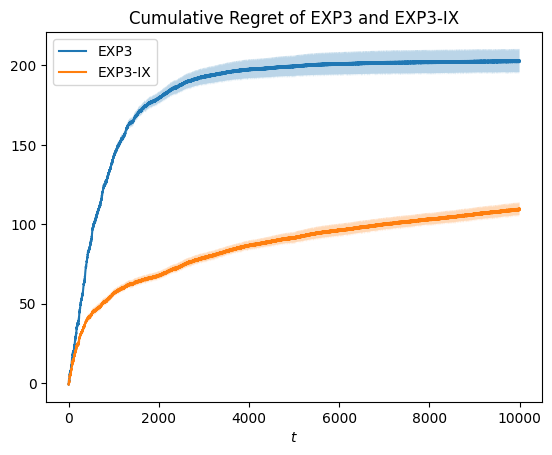

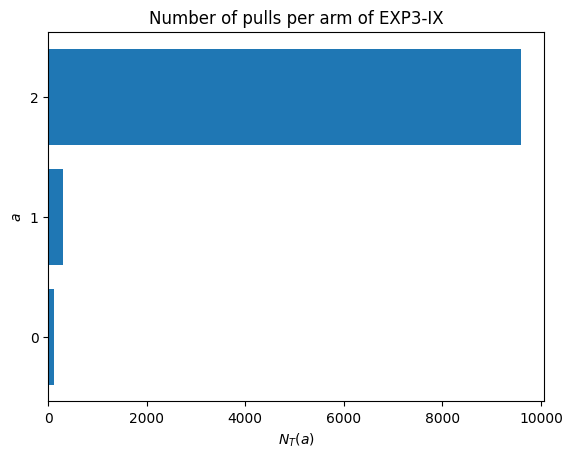

In [27]:
learning_rate = np.sqrt(np.log(K)/(K*T))

best_arm = np.argmin(loss_seq.sum(axis=0))
clairvoyant_losses = loss_seq[:, best_arm]
print('Best arm in hindsight:',best_arm)

n_trials = 10

exp3_regret_per_trial = []
exp3_ix_regret_per_trial = []
# we keep the loss sequence fixed, we will only observe uncertainty due to algorithm's randomizations
for trial in range(n_trials):
    print('Start trial', trial+1)
    np.random.seed(20+trial)
    agent = EXP3Agent(K, learning_rate=learning_rate)
    env = AdversarialBanditEnvironment(loss_seq)
    
    expected_agent_losses = []
    agent_losses = []
    for t in range(T):
        a_t = agent.pull_arm()
        l_t = env.round(a_t)
        agent.update(l_t)
        # logging
        expected_agent_losses.append(np.dot(agent.x_t,
                                            env.loss_sequence[t-1,:]))
        agent_losses.append(l_t)

    expected_agent_losses = np.array(expected_agent_losses)
    # expected_agent_losses = np.array(agent_losses)
    cumulative_regret = np.cumsum(expected_agent_losses-clairvoyant_losses)
    exp3_regret_per_trial.append(cumulative_regret)


    np.random.seed(20+trial)
    agent = AnytimeEXP3IXAgent(K)
    env = AdversarialBanditEnvironment(loss_seq)
    
    expected_agent_losses = []
    agent_losses = []
    for t in range(T):
        a_t = agent.pull_arm()
        l_t = env.round(a_t)
        agent.update(l_t)
        # logging
        expected_agent_losses.append(np.dot(agent.x_t,
                                            env.loss_sequence[t-1,:]))
        agent_losses.append(l_t)

    expected_agent_losses = np.array(expected_agent_losses)
    # expected_agent_losses = np.array(agent_losses)
    cumulative_regret = np.cumsum(expected_agent_losses-clairvoyant_losses)
    exp3_ix_regret_per_trial.append(cumulative_regret)

exp3_regret_per_trial = np.array(exp3_regret_per_trial)
exp3_ix_regret_per_trial = np.array(exp3_ix_regret_per_trial)

exp3_average_regret = exp3_regret_per_trial.mean(axis=0)
exp3_regret_sd = exp3_regret_per_trial.std(axis=0)
exp3_ix_average_regret = exp3_ix_regret_per_trial.mean(axis=0)
exp3_ix_regret_sd = exp3_ix_regret_per_trial.std(axis=0)

plt.plot(np.arange(T), exp3_average_regret, label='EXP3')
plt.fill_between(np.arange(T),
                exp3_average_regret-exp3_regret_sd/np.sqrt(n_trials),
                exp3_average_regret+exp3_regret_sd/np.sqrt(n_trials),
                alpha=0.3)
plt.plot(np.arange(T), exp3_ix_average_regret, label='EXP3-IX')
plt.fill_between(np.arange(T),
                exp3_ix_average_regret-exp3_ix_regret_sd/np.sqrt(n_trials),
                exp3_ix_average_regret+exp3_ix_regret_sd/np.sqrt(n_trials),
                alpha=0.3)
plt.title('Cumulative Regret of EXP3 and EXP3-IX')
plt.xlabel('$t$')
plt.legend()
plt.show()

# last trial only
plt.barh(y=['0','1','2'], width=agent.N_pulls)
plt.title('Number of pulls per arm of EXP3-IX')
plt.ylabel('$a$')
plt.xlabel('$N_T(a)$')
plt.show()

### Now we can use EXP3-IX to develop an algorithm for constrained problems with bandit feedback

In [28]:
class OGDEXP3IXMultiKnapsackAgent:
    def __init__(self, K, rho, T, ogd_eta):
        self.K = K
        self.m = len(rho)
        self.primal_minimizer = AnytimeEXP3IXAgent(self.K)
        self.budget = rho*T
        self.ogd_eta = ogd_eta
        self.T = T
        self.rho = rho # vector
        self.lmbd = np.ones(self.m) # vector
        self.t = 0
        self.N_pulls = np.zeros(K)
        self.a_t = 0

    def pull_arm(self):
        if (self.budget < 1).any():
            self.a_t = 0
            return 0
        self.a_t = self.primal_minimizer.pull_arm()
        return self.a_t
    
    def update(self, f_ta, c_ta):
        # f_ta sclar reward, c_ta vector of M costs
        # update hedge
        primal_reward_t = f_ta - self.lmbd @ c_ta # in [-1,+1] component-wise
        primal_reward_t = (primal_reward_t + 1) / 2 # either rescale in [0,1] or slightly change eta

        self.primal_minimizer.update(1 -primal_reward_t) # we need to maximize L

        # update lagrangian multiplier
        self.lmbd = np.clip(
            self.lmbd - self.ogd_eta * (self.rho - c_ta),
            a_min=0, 
            a_max=1 / self.rho
        )
        # update budget
        self.budget -= c_ta
        # log
        self.N_pulls[self.a_t] += 1

In [29]:
rho = np.array([0.4,0.4])
f = np.array([0,0.8,0.5])
C = np.array([[0,0.6,0.3],
              [0,0.5,0.6]]) 

K = len(f)
M = C.shape[0]
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant_multi(f, C, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

T = 10**5
ogd_eta = 1/np.sqrt(T)
agent = OGDEXP3IXMultiKnapsackAgent(K, rho=rho, T=T, ogd_eta=ogd_eta)


utilities = np.zeros(T)
costs = np.zeros((T,M))
lmbds = np.zeros((T,M))

rounds_with_depleted_budget = 0

np.random.seed(17)
F_samples = np.random.binomial(n=1, p=f, size=(T, K))
C_samples = np.random.binomial(1, C, size=(T, M, K))
env = MultiCostraintEnvironment(F_samples,C_samples)
for t in range(T):
    # interaction
    a_t = agent.pull_arm()
    f_t, C_t = env.round()
    agent.update(f_t[a_t], C_t[:,a_t])

    # logging
    utilities[t] = f_t[a_t]
    costs[t] = C_t[:,a_t]
    lmbds[t] = agent.lmbd
    if((agent.budget < 1).any() and rounds_with_depleted_budget==0):
        rounds_with_depleted_budget = T - t

Distribution: [0.23809524 0.57142857 0.19047619]
Utility: 0.5523809523809524
Cost: [0.4 0.4]


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\s'
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\3362819314.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\3362819314.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\3362819314.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.legend([f"$\lambda_{{{i}}}$" for i in range(lmbds.shape[1])])
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\3362819314.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sum 

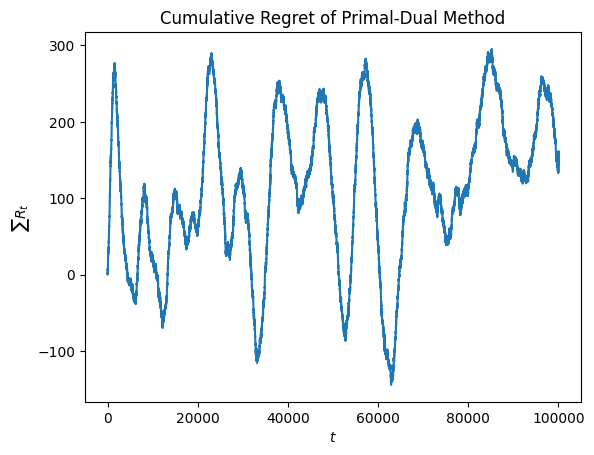

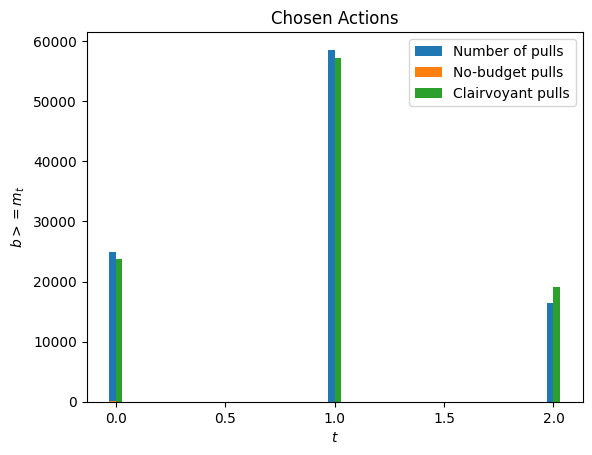

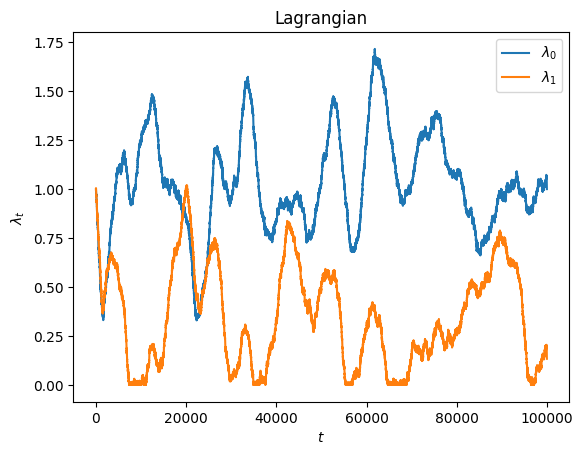

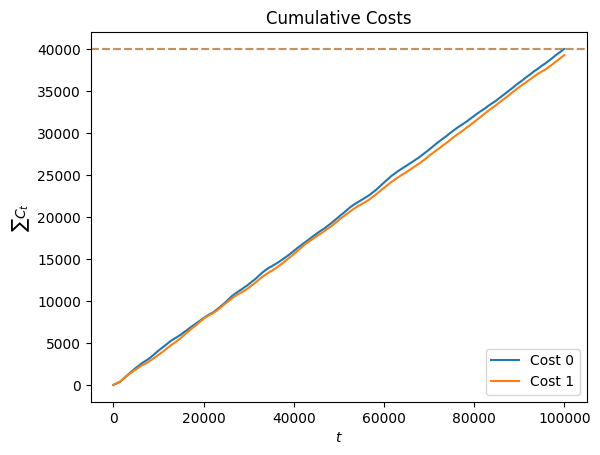

In [30]:
cumulative_regret = np.cumsum(clairvoyant_utility-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method')
plt.show()

plt.title("Chosen Actions")
width = 0.03
plt.bar(np.arange(K) -width/2, agent.N_pulls, width=width, align='center', label='Number of pulls')
plt.bar(0 -width/2, rounds_with_depleted_budget, width=width, align='center', label='No-budget pulls')
plt.bar(np.arange(K) +width/2, clairvoyant_x*T, width=width, align='center', label='Clairvoyant pulls')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

plt.plot(lmbds)
plt.xlabel('$t$')
plt.ylabel('$\lambda_t$')
plt.legend([f"$\lambda_{{{i}}}$" for i in range(lmbds.shape[1])])
plt.title('Lagrangian')
plt.show()

cum_costs = np.cumsum(costs, axis=0)
lines = plt.plot(cum_costs)
for i in range(M):
    plt.axhline(y=rho[i]*T, color=lines[i].get_color(), linestyle='--', alpha=0.6)
plt.legend([f"Cost {i}" for i in range(costs.shape[1])])
plt.xlabel("$t$")
plt.ylabel("$\sum C_t$")
plt.title("Cumulative Costs")
plt.show()

### To complete the estimation you need to average over multiple trials

## Soft constraints

### In a soft constraint setting there is no budget. Instead, every constraint has a threshold $\rho_i$ and is violated when $c_{t,i}(a_t) \ge \rho_i$.
### We want to minimize both the regret and the violation:
### $$ V_i = \mathbb{E}\left[ \sum_{t \in [T]} c_{t,i}(a_t) - \rho_i \right] \quad \forall i \in [M] $$

### Main differences w.r.t. previos algorithms:
- ### No need to stop due to depleted budget.
- ### Play a linear convex combination of the strategy provided bythe primal regret minimizer and the center of the simplex.

In [38]:
class HedgeAgentCC:
    def __init__(self, K, learning_rate, sigma):
        self.K = K
        self.learning_rate = learning_rate
        self.sigma = sigma
        self.weights = np.ones(K)
        self.x_t = np.ones(K)/K
        self.a_t = None
        self.t = 0

    def choose_distribution(self):
        self.x_t = (1-self.sigma)*self.weights/sum(self.weights) + self.sigma * np.ones(self.K) / self.K
        # self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        # slight difference: we return x_t
        self.x_t = self.x_t / np.sum(self.x_t)
        return self.x_t
    
    def update(self, l_t):
        self.weights *= np.exp(-self.learning_rate*l_t)
        self.t += 1

In [39]:
class OGDHedgeMultiConstraintsAgent:
    def __init__(self, K, rho, T, hedge_eta, ogd_eta):
        self.K = K
        self.m = len(rho)
        self.hedge = HedgeAgentCC(self.K, hedge_eta,1/T)
        self.ogd_eta = ogd_eta
        self.T = T
        self.rho = rho # vector
        self.lmbd = np.ones(self.m) # vector
        self.t = 0
        self.N_pulls = np.zeros(K)
        self.x_t = np.ones(K)
        self.a_t = 0

    def pull_arm(self):
        self.x_t = self.hedge.choose_distribution()
        self.a_t = np.random.choice(np.arange(self.K), p=self.x_t)
        return self.a_t
    
    def update(self, f_t, C_t):
        # f_t vector of rewards, C_t matrix of costs (M,K) all in [0,1]
        # update hedge
        # primal_reward_t[i] = f_t[i] - np.dot(lmbd,C_t[:,i]) for every constraint i
        primal_reward_t = f_t - self.lmbd @ C_t # in [-1,+1] component-wise
        primal_reward_t = (primal_reward_t + 1) / 2 # either rescale in [0,1] or slightly change eta

        self.hedge.update(1 -primal_reward_t) # we need to maximize L

        # update lagrangian multiplier
        # self.lmbd = self.lmbd - self.ogd_eta * (self.rho - C_t @ self.x_t)
        self.lmbd = np.clip(
            self.lmbd - self.ogd_eta * (self.rho - C_t @ self.x_t),
            a_min=0, 
            a_max=1 / self.rho
        )
        # log
        self.N_pulls[self.a_t] += 1

In [40]:
rho = np.array([0.6,0.5,0.4])
f = np.array([0.7,0.5,0.6])
C = np.array([[0.3,0.6,0.2],
              [0.6,0.3,0.5],
              [0.5,0.3,0.2]]) 

K = len(f)
M = C.shape[0]
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant_multi(f, C, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

Distribution: [0.57142857 0.28571429 0.14285714]
Utility: 0.6285714285714286
Cost: [0.37142857 0.5        0.4       ]


In [42]:
rho = np.array([0.6,0.5,0.4])
f = np.array([0.7,0.5,0.6])
C = np.array([[0.3,0.6,0.2],
              [0.6,0.3,0.5],
              [0.5,0.3,0.2]])

K = len(f)
M = C.shape[0]
clairvoyant_x, clairvoyant_utility, clairvoyant_cost = compute_clairvoyant_multi(f, C, rho)
print("Distribution:",clairvoyant_x)
print("Utility:",clairvoyant_utility)
print("Cost:",clairvoyant_cost)

T = 10**4
ogd_eta = 1/np.sqrt(T)
hedge_eta = np.sqrt(np.log(K)/T)
agent = OGDHedgeMultiConstraintsAgent(K, rho=rho, T=T, ogd_eta=ogd_eta, hedge_eta=hedge_eta)

utilities = np.zeros(T)
violations = np.zeros((T,M))
lmbds = np.zeros((T,M))

np.random.seed(17)
F_samples = np.random.binomial(n=1, p=f, size=(T, K))
C_samples = np.random.binomial(1, C, size=(T, M, K))
env = MultiCostraintEnvironment(F_samples,C_samples)
for t in range(T):
    # interaction
    a_t = agent.pull_arm()
    f_t, C_t = env.round()
    agent.update(f_t, C_t)

    # logging
    utilities[t] = f_t @ agent.x_t
    costs = C_t @ agent.x_t
    violations[t] = costs-rho
    lmbds[t] = agent.lmbd

Distribution: [0.57142857 0.28571429 0.14285714]
Utility: 0.6285714285714286
Cost: [0.37142857 0.5        0.4       ]


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\2368098532.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sum R_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\2368098532.py:27: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\lambda_t$')
C:\Users\matteo\AppData\Local\Temp\ipykernel_27072\2368098532.py:28: SyntaxWarning: invalid escape sequence '\l'
  plt.legend([f"$\lambda_{{{i}}}$" for i in range(lmbds.shape[1])])


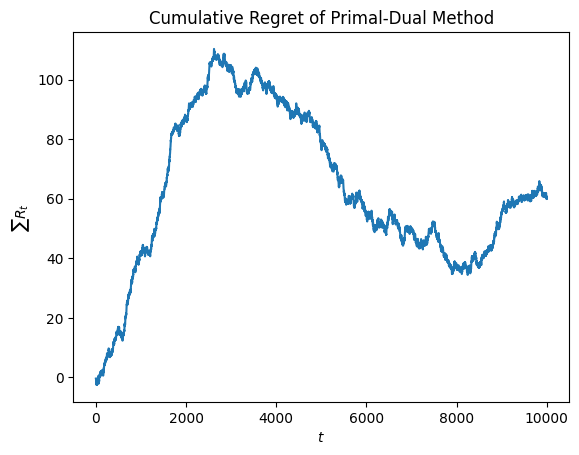

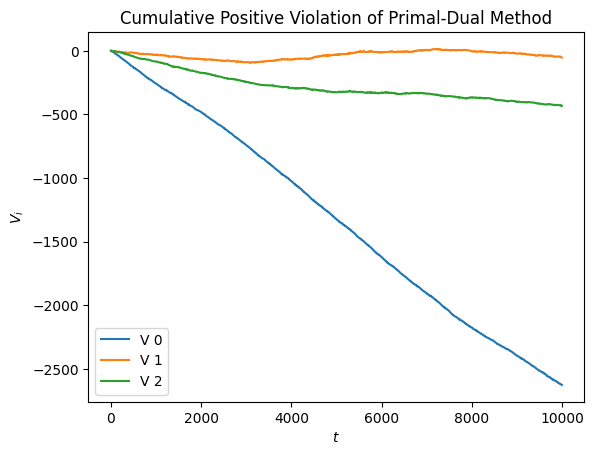

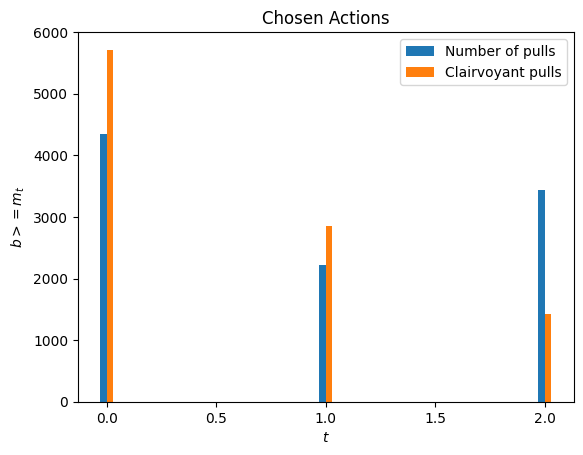

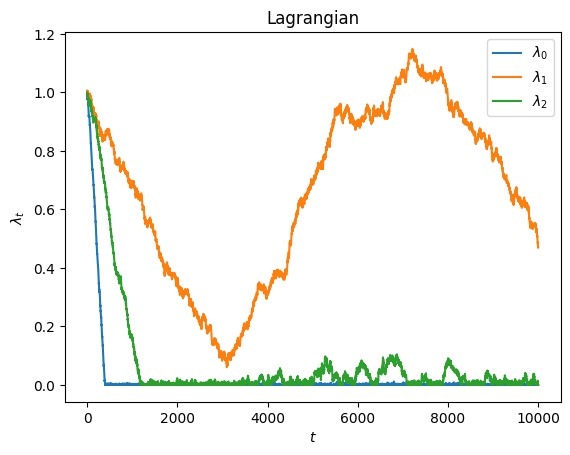

In [43]:
cumulative_regret = np.cumsum(clairvoyant_utility-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of Primal-Dual Method')
plt.show()

cumulative_violations = np.cumsum(violations, axis=0)
plt.plot(cumulative_violations)
plt.legend([f"V {i}" for i in range(violations.shape[1])])
plt.xlabel('$t$')
plt.ylabel('$V_i$')
plt.title('Cumulative Positive Violation of Primal-Dual Method')
plt.show()

plt.title("Chosen Actions")
width = 0.03
plt.bar(np.arange(K) -width/2, agent.N_pulls, width=width, align='center', label='Number of pulls')
plt.bar(np.arange(K) +width/2, clairvoyant_x*T, width=width, align='center', label='Clairvoyant pulls')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

plt.plot(lmbds)
plt.xlabel('$t$')
plt.ylabel('$\lambda_t$')
plt.legend([f"$\lambda_{{{i}}}$" for i in range(lmbds.shape[1])])
plt.title('Lagrangian')
plt.show()

### For the stochastic setting, there are algorithms that can boundthe positive violation (i.e., rounds with negative contributions are not considered)